### Importa los datos
Dataset con diferentes fármacos, sus efectos y ratings de los clientes.

Importa el dataset *drugLibTrain_raw.tsv*

In [28]:
import pandas as pd

In [29]:
drug = pd.read_csv('./data/drugLibTrain_raw.tsv', sep='\t')

### Descriptive Analysis

Quedate únicamente con las columnas que podamos manejar: Columnas numéricas y columnas categóricas con pocas categorías (menos de 10)

In [30]:
drug.head()

,Unnamed: 0,urlDrugName,rating,effectiveness,sideEffects,condition,benefitsReview,sideEffectsReview,commentsReview
0,2202,enalapril,4,Highly Effective,Mild Side Effects,management of congestive heart failure,slowed the progression of left ventricular dys...,"cough, hypotension , proteinuria, impotence , ...","monitor blood pressure , weight and asses for ..."
1,3117,ortho-tri-cyclen,1,Highly Effective,Severe Side Effects,birth prevention,Although this type of birth control has more c...,"Heavy Cycle, Cramps, Hot Flashes, Fatigue, Lon...","I Hate This Birth Control, I Would Not Suggest..."
2,1146,ponstel,10,Highly Effective,No Side Effects,menstrual cramps,I was used to having cramps so badly that they...,Heavier bleeding and clotting than normal.,I took 2 pills at the onset of my menstrual cr...
3,3947,prilosec,3,Marginally Effective,Mild Side Effects,acid reflux,The acid reflux went away for a few months aft...,"Constipation, dry mouth and some mild dizzines...",I was given Prilosec prescription at a dose of...
4,1951,lyrica,2,Marginally Effective,Severe Side Effects,fibromyalgia,I think that the Lyrica was starting to help w...,I felt extremely drugged and dopey. Could not...,See above


In [31]:
drug.info()

<class 'pandas.DataFrame'>
RangeIndex: 3107 entries, 0 to 3106
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Unnamed: 0         3107 non-null   int64
 1   urlDrugName        3107 non-null   str  
 2   rating             3107 non-null   int64
 3   effectiveness      3107 non-null   str  
 4   sideEffects        3107 non-null   str  
 5   condition          3106 non-null   str  
 6   benefitsReview     3089 non-null   str  
 7   sideEffectsReview  3032 non-null   str  
 8   commentsReview     3095 non-null   str  
dtypes: int64(2), str(7)
memory usage: 2.3 MB


In [32]:
drug =  drug.rename(columns={'Unnamed: 0':'id'})

In [33]:
drug.columns

Index(['id', 'urlDrugName', 'rating', 'effectiveness', 'sideEffects',
       'condition', 'benefitsReview', 'sideEffectsReview', 'commentsReview'],
      dtype='str')

In [34]:
drug.isna().sum()

id                    0
urlDrugName           0
rating                0
effectiveness         0
sideEffects           0
condition             1
benefitsReview       18
sideEffectsReview    75
commentsReview       12
dtype: int64

In [35]:
for col in drug.columns:
    print(f'{col}: {drug[col].nunique()}')

id: 3107
urlDrugName: 502
rating: 10
effectiveness: 5
sideEffects: 5
condition: 1426
benefitsReview: 3031
sideEffectsReview: 2813
commentsReview: 3046


In [36]:
X = drug[['rating','effectiveness','sideEffects']]

In [37]:
X.head()

,rating,effectiveness,sideEffects
0,4,Highly Effective,Mild Side Effects
1,1,Highly Effective,Severe Side Effects
2,10,Highly Effective,No Side Effects
3,3,Marginally Effective,Mild Side Effects
4,2,Marginally Effective,Severe Side Effects


#### Transforma las columnas categóricas

Transforma las columnas categoricas a numericas mediante dummies

In [38]:
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler

In [39]:
scl = MinMaxScaler()

X_s = scl.fit_transform(X[['rating']])

X = pd.concat([X, pd.DataFrame(X_s)], axis=1)
X = X.drop(columns=['rating'])
X

,effectiveness,sideEffects,0
0,Highly Effective,Mild Side Effects,0.333333
1,Highly Effective,Severe Side Effects,0.000000
2,Highly Effective,No Side Effects,1.000000
3,Marginally Effective,Mild Side Effects,0.222222
4,Marginally Effective,Severe Side Effects,0.111111
...,...,...,...
3102,Highly Effective,Mild Side Effects,1.000000
3103,Ineffective,Extremely Severe Side Effects,0.000000
3104,Marginally Effective,Moderate Side Effects,0.111111
3105,Considerably Effective,Mild Side Effects,0.777778


In [42]:
X = X.rename({0:'rating'}, axis=1)

In [55]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 3107 entries, 0 to 3106
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   effectiveness  3107 non-null   str    
 1   sideEffects    3107 non-null   str    
 2   rating         3107 non-null   float64
dtypes: float64(1), str(2)
memory usage: 183.0 KB


In [43]:
ohe = OneHotEncoder(drop='first')
X_enc = ohe.fit_transform(X)

In [54]:
print(X_enc)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 7913 stored elements and shape (3107, 17)>
  Coords	Values
  (0, 0)	1.0
  (0, 4)	1.0
  (0, 10)	1.0
  (1, 0)	1.0
  (1, 7)	1.0
  (2, 0)	1.0
  (2, 6)	1.0
  (2, 16)	1.0
  (3, 2)	1.0
  (3, 4)	1.0
  (3, 9)	1.0
  (4, 2)	1.0
  (4, 7)	1.0
  (4, 8)	1.0
  (5, 1)	1.0
  (5, 7)	1.0
  (6, 0)	1.0
  (6, 4)	1.0
  (6, 15)	1.0
  (7, 6)	1.0
  (7, 16)	1.0
  (8, 0)	1.0
  (8, 6)	1.0
  (8, 16)	1.0
  (9, 1)	1.0
  :	:
  (3096, 4)	1.0
  (3096, 13)	1.0
  (3097, 6)	1.0
  (3097, 14)	1.0
  (3098, 0)	1.0
  (3098, 6)	1.0
  (3098, 16)	1.0
  (3099, 5)	1.0
  (3099, 14)	1.0
  (3100, 4)	1.0
  (3100, 13)	1.0
  (3101, 6)	1.0
  (3101, 14)	1.0
  (3102, 0)	1.0
  (3102, 4)	1.0
  (3102, 16)	1.0
  (3103, 1)	1.0
  (3104, 2)	1.0
  (3104, 5)	1.0
  (3104, 8)	1.0
  (3105, 4)	1.0
  (3105, 14)	1.0
  (3106, 3)	1.0
  (3106, 5)	1.0
  (3106, 10)	1.0


#### Evalua cual es la mejor K

Utiliza silhouette_score para evaluar cual es la mejor K.

#### Genera el K Means 

In [45]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [46]:
kmeans_per_k = [KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_enc)
                for k in range(1, 20)]

In [47]:
silhouette_scores = [silhouette_score(X_enc, model.labels_) for model in kmeans_per_k[1:]]

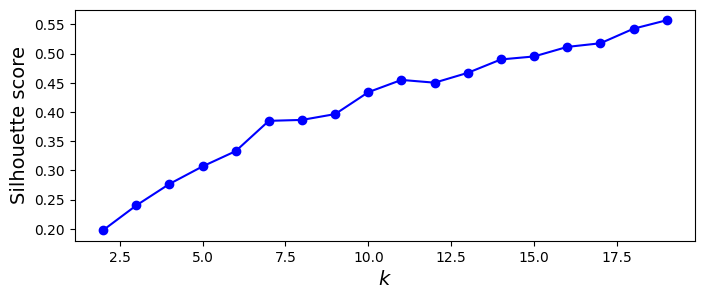

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 3))
plt.plot(range(2, 20), silhouette_scores, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Silhouette score", fontsize=14)
#plt.axis([1.8, 20.5, 0.55, 0.7])
plt.show()

Comprueba los resultados y muestra en un pie plot la distribución de los distintos clusters.

Eeeh, no se que estoy haciendo.